# Imports

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import utils.UVA as UVA
import utils.MVA as MVA
import utils.PCA as PCA

from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.decomposition import PCA as skPCA
from sklearn.compose import ColumnTransformer

from sklearn.cluster import KMeans, DBSCAN, MiniBatchKMeans, AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples

from sklearn.metrics.cluster import adjusted_rand_score

In [184]:
df = pd.read_csv('data/clean_df_customers.csv')
df.set_index('customer_unique_id', inplace=True)

df

,recency,baby,computers,fixed_telephony,furniture_decor,musical_instruments,sports_leisure,telephony,toys,other_categories,freight_value,frequency_medium,mean_review_score,ratio_comment_message,max_order_date
customer_unique_id,,,,,,,,,,,,,,,
7c396fd4830fd04220f754e42b4e5bff,380,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.44,1,4,100.0,2017-10-02
af07308b275d755c9edb36a90c618231,85,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,118.7,22.76,0,4,100.0,2018-07-24
3a653a41f6f9fc3d2a113cf8398680e8,70,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.22,1,5,0.0,2018-08-08
7c142cf63193a1473d2e66489a9ae977,333,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0,27.20,1,3,100.0,2017-11-18
72632f0f9dd73dfee390c9b22eb56dd6,246,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.9,8.72,0,5,0.0,2018-02-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6359f309b166b0196dbf7ad2ac62bb5a,587,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.08,1,1,0.0,2017-03-09
da62f9e57a76d978d02ab5362c509660,253,174.90,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.10,0,5,100.0,2018-02-06
737520a9aad80b3fbbdad19b66b37b30,416,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,65.02,0,5,100.0,2017-08-27


In [185]:
offset = -2
n_periods = 18

#list_offsets = [i for i in range(n_offset, n_periods+n_offset, n_offset)]
list_offsets = list(range(n_periods, 0, offset))
list_offsets

[18, 16, 14, 12, 10, 8, 6, 4, 2]

In [186]:
offset = -1
n_periods_max = 30
n_periods_min = 15

#list_offsets = [i for i in range(n_offset, n_periods+n_offset, n_offset)]
list_offsets = list(range(n_periods_max, n_periods_min, offset))
list_offsets

[30, 29, 28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16]

In [187]:
min_date = pd.to_datetime(df['max_order_date'].min())
max_date = pd.to_datetime(df['max_order_date'].max())

print(min_date.strftime('%Y-%m-%d'))
print(max_date.strftime('%Y-%m-%d'))

2016-09-04
2018-10-16


In [188]:
n_period_sp = 5
limit_date = (max_date - pd.DateOffset(weeks=list_offsets[n_period_sp])).strftime('%Y-%m-%d')

print (f"Date max {max_date.strftime('%Y-%m-%d')} après retrait de {n_period_sp} semaines : {limit_date}")

Date max 2018-10-16 après retrait de 5 semaines : 2018-04-24


In [189]:
dfs = {}

#list_n_df
#len_offsets = len(list_offsets)
#offsets_count = list(range(1, len_offsets, 1))
n = 1

for i in list_offsets:
    subset = df[df['max_order_date'] <= (max_date - pd.DateOffset(weeks=i)).strftime('%Y-%m-%d')]
    #dfs[f'df_{i}'] = subset
    dfs[f'df_{n}'] = subset
    n+=1

print(dfs.keys())

dict_keys(['df_1', 'df_2', 'df_3', 'df_4', 'df_5', 'df_6', 'df_7', 'df_8', 'df_9', 'df_10', 'df_11', 'df_12', 'df_13', 'df_14', 'df_15'])


In [196]:
dfs['df_1']['max_order_date'].max()

'2018-03-20'

In [202]:
for name, df in dfs.items():
    print(f'{name}: shape {df.shape}, max date {df.max_order_date.max()}')
    #print()

df_1: shape (60935, 15), max date 2018-03-20
df_2: shape (62523, 15), max date 2018-03-27
df_3: shape (63974, 15), max date 2018-04-03
df_4: shape (65453, 15), max date 2018-04-10
df_5: shape (67058, 15), max date 2018-04-17
df_6: shape (68697, 15), max date 2018-04-24
df_7: shape (70274, 15), max date 2018-05-01
df_8: shape (72207, 15), max date 2018-05-08
df_9: shape (74162, 15), max date 2018-05-15
df_10: shape (75654, 15), max date 2018-05-22
df_11: shape (76482, 15), max date 2018-05-29
df_12: shape (77665, 15), max date 2018-06-05
df_13: shape (79203, 15), max date 2018-06-12
df_14: shape (80637, 15), max date 2018-06-19
df_15: shape (82082, 15), max date 2018-06-26


In [203]:
# drop max_order_date column
for name, df in dfs.items():
    df = df.drop('max_order_date', axis=1)
    dfs[name] = df

for name, df in dfs.items():
    print(f'{name}: {df.shape}')
    #print()

df_1: (60935, 14)
df_2: (62523, 14)
df_3: (63974, 14)
df_4: (65453, 14)
df_5: (67058, 14)
df_6: (68697, 14)
df_7: (70274, 14)
df_8: (72207, 14)
df_9: (74162, 14)
df_10: (75654, 14)
df_11: (76482, 14)
df_12: (77665, 14)
df_13: (79203, 14)
df_14: (80637, 14)
df_15: (82082, 14)


In [204]:
dfs['df_1']

,recency,baby,computers,fixed_telephony,furniture_decor,musical_instruments,sports_leisure,telephony,toys,other_categories,freight_value,frequency_medium,mean_review_score,ratio_comment_message
customer_unique_id,,,,,,,,,,,,,,
7c396fd4830fd04220f754e42b4e5bff,380,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.44,1,4,100.0
7c142cf63193a1473d2e66489a9ae977,333,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0,27.20,1,3,100.0
72632f0f9dd73dfee390c9b22eb56dd6,246,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.9,8.72,0,5,0.0
80bb27c7c16e8f973207a5086ab329e2,465,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,27.36,0,4,0.0
36edbb3fb164b1f16485364b6fb04c73,554,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49.9,16.05,1,5,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6359f309b166b0196dbf7ad2ac62bb5a,587,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.08,1,1,0.0
da62f9e57a76d978d02ab5362c509660,253,174.90,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.10,0,5,100.0
737520a9aad80b3fbbdad19b66b37b30,416,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,65.02,0,5,100.0


# train kmeans datasets

In [205]:
skewness = dfs['df_1'].select_dtypes(include=np.number).skew()
treshold_skew = 1.0
cols_skewed = skewness[skewness > treshold_skew].index.tolist()
cols_unskewed = skewness[skewness < treshold_skew].index.tolist()

print("Colonnes numériques avec une skewness supérieure à la limite :")
print(cols_skewed)
print(cols_unskewed)


Colonnes numériques avec une skewness supérieure à la limite :
['baby', 'computers', 'fixed_telephony', 'furniture_decor', 'musical_instruments', 'sports_leisure', 'telephony', 'toys', 'other_categories', 'freight_value', 'frequency_medium']
['recency', 'mean_review_score', 'ratio_comment_message']


In [206]:
def customTransform(df, cols_skewed, cols_unskewed):
    # sélection colonnes avec skewness élevée :
    
    # Création du ColumnTransformer
    transformer = ColumnTransformer([
        #('minmax', MinMaxScaler(), cols_skewed),
        ('power', PowerTransformer(), cols_skewed),
        ('standard', StandardScaler(), cols_unskewed)
    ])
    
    X_std = pd.DataFrame(transformer.fit_transform(df), columns=df.columns)
    return X_std

In [207]:
# drop max_order_date column
X_stds = {}

for name, df in dfs.items():
    df = customTransform(df, cols_skewed, cols_unskewed)
    name_split = name.split("_")
    X_stds[f'X_{name_split[1]}'] = df

In [208]:
X_stds.keys()

dict_keys(['X_1', 'X_2', 'X_3', 'X_4', 'X_5', 'X_6', 'X_7', 'X_8', 'X_9', 'X_10', 'X_11', 'X_12', 'X_13', 'X_14', 'X_15'])

In [209]:
for name, df in X_stds.items():
    print(f'{name}: {df.shape}')
    #print()

X_1: (60935, 14)
X_2: (62523, 14)
X_3: (63974, 14)
X_4: (65453, 14)
X_5: (67058, 14)
X_6: (68697, 14)
X_7: (70274, 14)
X_8: (72207, 14)
X_9: (74162, 14)
X_10: (75654, 14)
X_11: (76482, 14)
X_12: (77665, 14)
X_13: (79203, 14)
X_14: (80637, 14)
X_15: (82082, 14)


In [137]:
X_stds['X_1']

,recency,baby,computers,fixed_telephony,furniture_decor,musical_instruments,sports_leisure,telephony,toys,other_categories,freight_value,frequency_medium,mean_review_score,ratio_comment_message
0,5.824726,-0.045628,-0.049389,-0.271698,-0.08001,-0.301254,-0.220134,-0.216377,-0.558712,-0.120824,1.508335,0.227862,-0.013716,1.189009
1,-0.171682,-0.045628,-0.049389,-0.271698,-0.08001,-0.301254,-0.220134,-0.216377,1.778627,0.660092,1.508335,-0.143800,-0.731422,1.189009
2,-0.171682,-0.045628,-0.049389,-0.271698,-0.08001,-0.301254,-0.220134,-0.216377,1.693516,-1.407849,-0.661969,-0.831770,0.703990,-0.846335
3,-0.171682,-0.045628,-0.049389,-0.271698,-0.08001,-0.301254,-0.220134,-0.216377,-0.558712,0.670124,-0.661969,0.900017,-0.013716,-0.846335
4,-0.171682,-0.045628,-0.049389,-0.271698,-0.08001,-0.301254,-0.220134,-0.216377,1.785893,-0.271051,1.508335,1.603803,0.703990,1.189009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70269,-0.171682,-0.045628,-0.049389,-0.271698,-0.08001,-0.301254,-0.220134,-0.216377,-0.558712,-0.646300,1.508335,1.864757,-2.166834,-0.846335
70270,5.824726,-0.045628,-0.049389,-0.271698,-0.08001,-0.301254,-0.220134,-0.216377,-0.558712,0.132918,-0.661969,-0.776416,0.703990,1.189009
70271,-0.171682,-0.045628,-0.049389,-0.271698,-0.08001,-0.301254,-0.220134,-0.216377,-0.558712,2.066679,-0.661969,0.512539,0.703990,1.189009
70272,-0.171682,-0.045628,-0.049389,-0.271698,-0.08001,-0.301254,-0.220134,-0.216377,-0.558712,2.397529,-0.661969,-0.547093,0.703990,1.189009


## Check training first dataset

BatchKmeans 2 clusters, sil score : 0.07487581997765735
BatchKmeans 3 clusters, sil score : 0.12264576438103339
BatchKmeans 4 clusters, sil score : 0.192113833086153
BatchKmeans 5 clusters, sil score : 0.13212769768904614
BatchKmeans 6 clusters, sil score : 0.18043655778263726
BatchKmeans 7 clusters, sil score : 0.22391834872572597
BatchKmeans 8 clusters, sil score : 0.21360609125626542
BatchKmeans 9 clusters, sil score : 0.20281761125295897
BatchKmeans 10 clusters, sil score : 0.27336661871989765
BatchKmeans 11 clusters, sil score : 0.2325864791160824
BatchKmeans 12 clusters, sil score : 0.24244431821166657
BatchKmeans 13 clusters, sil score : 0.1975088502574024
BatchKmeans 14 clusters, sil score : 0.23711278856724205
BatchKmeans 15 clusters, sil score : 0.2195682096482675


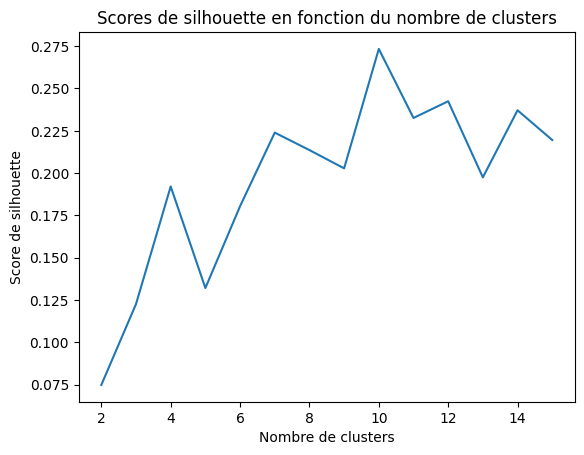

Le nombre optimal de clusters est : 10


In [210]:
X_std = X_stds['X_1'].copy()

# Calcul du score de silhouette pour chaque valeur de n_clusters comprise entre 2 et 15
n_clusters_range = range(2, 16)
scores = []

columns = X_std.columns

for n_clusters in n_clusters_range:
    # Initialisation de KMeans avec kmeans++
    
    #kmeans = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, max_iter=300, random_state=42)
    #kmeans.fit(X_std)
    #labels = kmeans.labels_
    #score = silhouette_score(X_std, labels)
    #print(f'Kmeans sil score : {score}')
    #scores.append(score)

    # Initialisation de MiniBatchKMeans
    mbkmeans = MiniBatchKMeans(n_clusters=n_clusters, init='k-means++', n_init=10, max_iter=300, batch_size=100, random_state=42)
    mbkmeans.fit(X_std)
    labels_mb = mbkmeans.labels_
    score_mb = silhouette_score(X_std, labels_mb)
    print(f'BatchKmeans {n_clusters} clusters, sil score : {score_mb}')
    scores.append(score_mb)

# Tracé du graphique des scores de silhouette
plt.plot(n_clusters_range, scores)
plt.xlabel('Nombre de clusters')
plt.ylabel('Score de silhouette')
plt.title('Scores de silhouette en fonction du nombre de clusters')
plt.show()

# Sélection de la valeur de n_clusters qui donne le score de silhouette le plus élevé
best_score = max(scores)
best_index = scores.index(best_score)
best_n_clusters = best_index + 2

print(f"Le nombre optimal de clusters est : {best_n_clusters}")

In [211]:
sorted_scores = np.argsort(scores)[::-1]
top_indices = sorted_scores[:5]

print("Les 5 plus grands score de silhouette sont :")

for indice in top_indices:
    print(f"{indice+2} clusters pour {scores[indice]} score de silhouette")

Les 5 plus grands score de silhouette sont :
10 clusters pour 0.27336661871989765 score de silhouette
12 clusters pour 0.24244431821166657 score de silhouette
14 clusters pour 0.23711278856724205 score de silhouette
11 clusters pour 0.2325864791160824 score de silhouette
7 clusters pour 0.22391834872572597 score de silhouette


In [212]:
inertia = {}
dict_kmeans = {}
for k in range(1,25):
    print(k)
    kmeans = KMeans(n_clusters=k,
                   verbose=1,
                   random_state=0
                   ).fit(X_std)
    inertia[k] = kmeans.inertia_
    dict_kmeans[k] = kmeans

1
Initialization complete
Iteration 0, inertia 1139392.817484197.
Iteration 1, inertia 853090.0000000013.
Converged at iteration 1: strict convergence.
2
Initialization complete
Iteration 0, inertia 1069031.8075400833.
Iteration 1, inertia 789308.0678005337.
Iteration 2, inertia 789298.55192506.
Converged at iteration 2: strict convergence.
3
Initialization complete
Iteration 0, inertia 854675.3292545301.
Iteration 1, inertia 763777.5966827155.
Iteration 2, inertia 762145.0842845606.
Iteration 3, inertia 761235.206924842.
Iteration 4, inertia 760635.349714316.
Iteration 5, inertia 760263.2901757366.
Iteration 6, inertia 760059.7203792655.
Iteration 7, inertia 759904.6741924362.
Iteration 8, inertia 759759.3858300957.
Iteration 9, inertia 759633.5079476797.
Iteration 10, inertia 759521.7739988414.
Iteration 11, inertia 759418.5701065973.
Iteration 12, inertia 759312.1627152767.
Iteration 13, inertia 759197.6441402545.
Iteration 14, inertia 759066.5249631181.
Iteration 15, inertia 758926

<AxesSubplot:title={'center':'Kmeans : Comparaison de la somme des inerties en fonction du nombre de clusters'}>

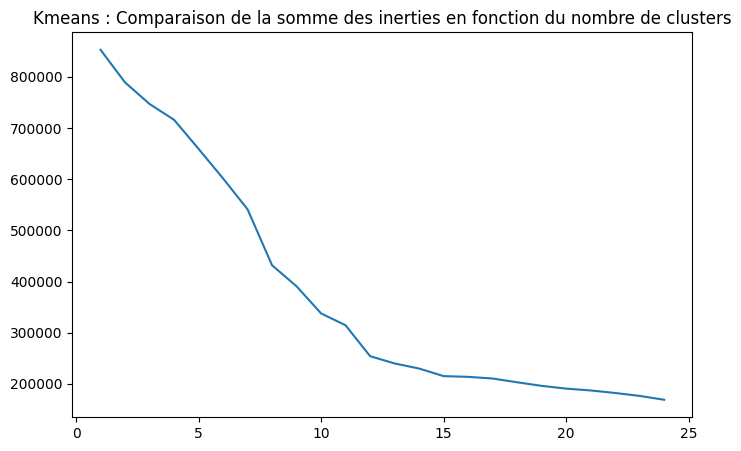

In [213]:
plt.figure(figsize=(8,5))
plt.title('Kmeans : Comparaison de la somme des inerties en fonction du nombre de clusters')
sns.lineplot(x=list(inertia.keys()),
             y=list(inertia.values())
            )

### Train and compare through time

In [214]:
clusters_num = 10

dict_Kmeans_X = {}

for name, df in X_stds.items():
    kmeans = KMeans(n_clusters=clusters_num, verbose=1, random_state=0).fit(df)
    dict_Kmeans_X[f'kmeans_{name}'] = kmeans

Initialization complete
Iteration 0, inertia 492886.23772506695.
Iteration 1, inertia 355172.73159436806.
Iteration 2, inertia 353898.72465359536.
Iteration 3, inertia 353231.46816244384.
Iteration 4, inertia 352879.127042776.
Iteration 5, inertia 352667.2817414675.
Iteration 6, inertia 352502.55271069036.
Iteration 7, inertia 352350.0907538794.
Iteration 8, inertia 352200.06548959005.
Iteration 9, inertia 351990.12597695395.
Iteration 10, inertia 351697.6049357556.
Iteration 11, inertia 351232.9486171092.
Iteration 12, inertia 350665.271216725.
Iteration 13, inertia 350133.4547161604.
Iteration 14, inertia 349225.6362027855.
Iteration 15, inertia 346626.8682043769.
Iteration 16, inertia 339547.44273502147.
Iteration 17, inertia 337649.33827835915.
Iteration 18, inertia 337645.374023937.
Converged at iteration 18: strict convergence.
Initialization complete
Iteration 0, inertia 538196.3994750909.
Iteration 1, inertia 408611.4732440619.
Iteration 2, inertia 400104.9482406245.
Iteration 

# Compute ARI

In [215]:
scores = []
first_kmeans = dict_Kmeans_X['kmeans_X_1']

for name, kmeans in dict_Kmeans_X.items():
    X_name = name.replace("kmeans_", "")
    ari = adjusted_rand_score(kmeans.labels_, first_kmeans.predict(X_stds[X_name]))
    scores.append(ari)

In [216]:
scores

[1.0,
 0.42015756430260787,
 0.6522055996901441,
 0.4942564989773019,
 0.33364620342711054,
 0.4939749179874731,
 0.578689217756784,
 0.7344672034491264,
 0.5847835786054744,
 0.864859153169905,
 0.3916695896851945,
 0.6139670516729935,
 0.7970495533195081,
 0.9939246891978774,
 0.8067800261058201]

In [217]:
scores_len = len(scores)
periodes = list(range(0, scores_len, 1))

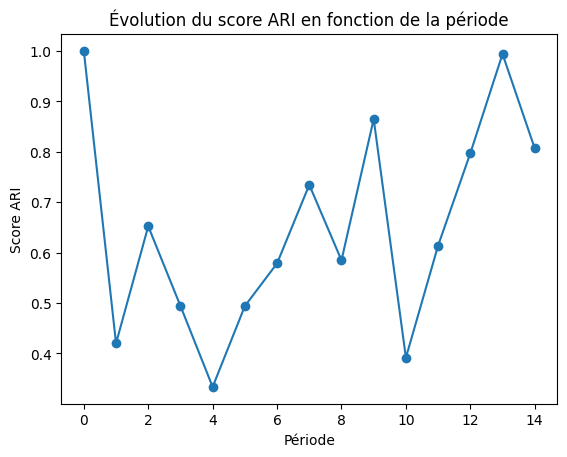

In [218]:
plt.plot(periodes, scores, marker='o')
plt.xlabel('Période')
plt.ylabel('Score ARI')
plt.title('Évolution du score ARI en fonction de la période')
plt.show()